In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/souissidonia/detection/other/default/1/best.pt


In [8]:
# Install required libraries:
# - ultralytics: YOLOv11 framework for object detection
# - roboflow: to download annotated datasets easily
!pip install ultralytics roboflow -q

print('Libraries installed successfully!')

Libraries installed successfully!


In [11]:
# Download the plant disease dataset from Roboflow
# This dataset contains annotated images of plant leaves with 13 disease categories
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="QqNnX0nbM704Qwyzzhif")
project = rf.workspace("donias-workspace-apjvd").project("plant-disease-kkt3g-k3m1u")
version = project.version(2)
dataset = version.download("yolov11")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 5.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 41.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 122.2 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-big


Extracting Dataset Version Zip to plant-disease-2 in yolov11:: 100%|██████████| 17191/17191 [00:01<00:00, 8692.44it/s] 


## Step 3 — Exploratory Data Analysis (EDA)
Before training, we analyze the dataset to understand:
- How many images we have
- How many instances per class (class imbalance)
- What the annotated images look like
- The distribution of bounding box sizes

In [20]:
# EDA - Step 3.1: Dataset Summary
# Load dataset configuration and print key statistics
import yaml
from pathlib import Path

# Load class names from the YAML config file
with open("/kaggle/working/plant-disease-2/data.yaml", "r") as f:
    data = yaml.safe_load(f)
class_names = data["names"]

# Map numeric class IDs to real disease names
# Note: dataset uses numeric labels; we map them to meaningful names
disease_names = {
    0: "Bacterial Blight",
    1: "Curl Virus",
    2: "Herbicide Injury",
    3: "Leaf Crinkle",
    4: "Leaf Curl",
    5: "Leaf Spot",
    6: "Mosaic Virus",
    7: "Powdery Mildew",
    8: "Sudden Death",
    9: "Target Spot",
    10: "Healthy",
    11: "Septoria Leaf Spot",
    12: "Yellow Leaf Curl"
}

# Count images in each split
train_imgs = len(list(Path("/kaggle/working/plant-disease-2/train/images").glob("*.jpg")))
val_imgs   = len(list(Path("/kaggle/working/plant-disease-2/valid/images").glob("*.jpg")))

print("=" * 45)
print("        DATASET SUMMARY")
print("=" * 45)
print(f"  Train images    : {train_imgs}")
print(f"  Val images      : {val_imgs}")
print(f"  Total images    : {train_imgs + val_imgs}")
print(f"  Total classes   : {len(class_names)}")
print("=" * 45)
print("  Disease Classes:")
for k, v in disease_names.items():
    print(f"    Class {k:2d}: {v}")
print("=" * 45)

        DATASET SUMMARY
  Train images    : 6867
  Val images      : 843
  Total images    : 7710
  Total classes   : 13
  Disease Classes:
    Class  0: Bacterial Blight
    Class  1: Curl Virus
    Class  2: Herbicide Injury
    Class  3: Leaf Crinkle
    Class  4: Leaf Curl
    Class  5: Leaf Spot
    Class  6: Mosaic Virus
    Class  7: Powdery Mildew
    Class  8: Sudden Death
    Class  9: Target Spot
    Class 10: Healthy
    Class 11: Septoria Leaf Spot
    Class 12: Yellow Leaf Curl


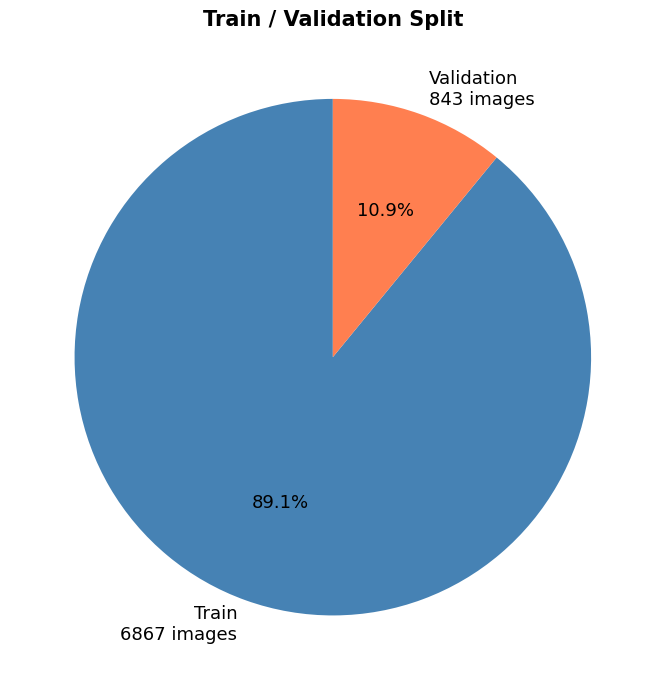

Train: 6867 images (89.1%)
Val  : 843 images (10.9%)


In [12]:
# EDA - Step 3.2: Train/Validation Split Visualization
# Shows the proportion of images used for training vs validation
import matplotlib.pyplot as plt
from pathlib import Path

train_imgs = len(list(Path("/kaggle/working/plant-disease-2/train/images").glob("*.jpg")))
val_imgs   = len(list(Path("/kaggle/working/plant-disease-2/valid/images").glob("*.jpg")))

plt.figure(figsize=(7, 7))
plt.pie(
    [train_imgs, val_imgs],
    labels=[f"Train\n{train_imgs} images", f"Validation\n{val_imgs} images"],
    colors=["steelblue", "coral"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 13}
)
plt.title("Train / Validation Split", fontsize=15, fontweight="bold")
plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/runs/train_val_split.png", dpi=150)
plt.show()
print(f"Train: {train_imgs} images ({100*train_imgs/(train_imgs+val_imgs):.1f}%)")
print(f"Val  : {val_imgs} images ({100*val_imgs/(train_imgs+val_imgs):.1f}%)")

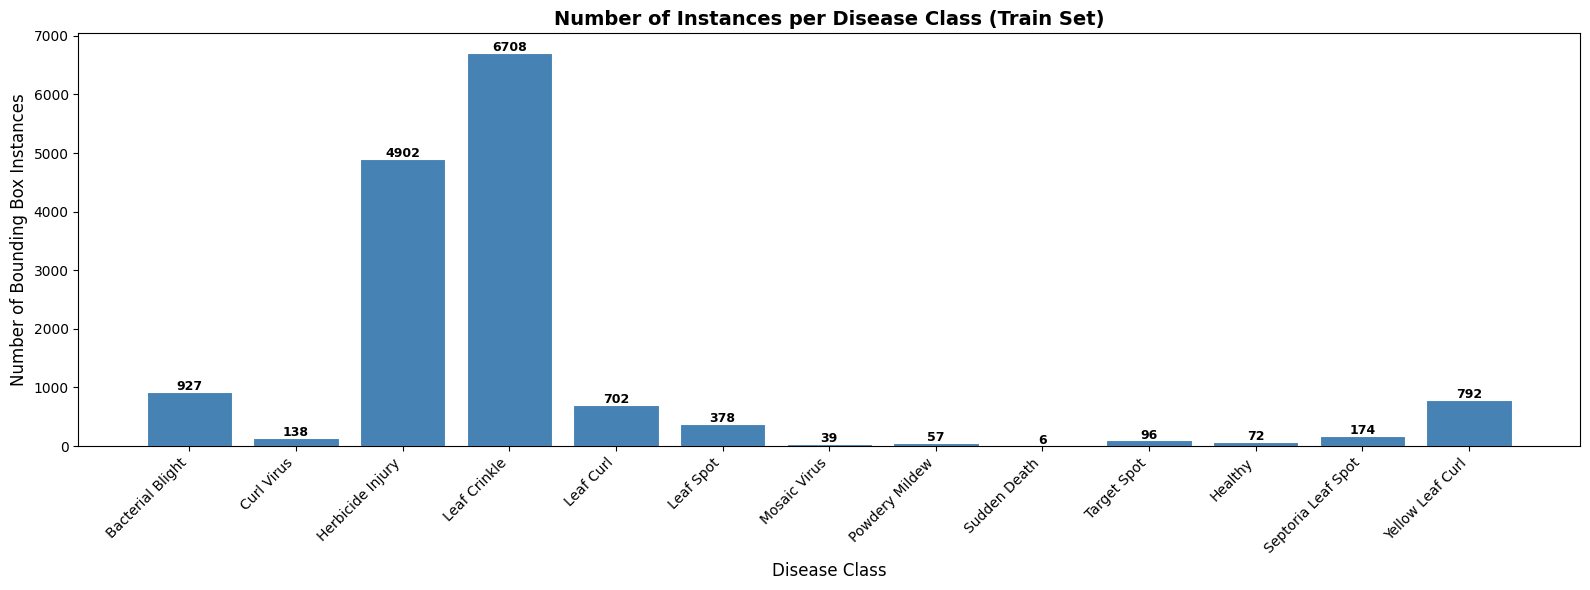

Most common class : Leaf Crinkle (6708 instances)
Least common class: Sudden Death (6 instances)
Class imbalance ratio: 1118.0x


In [15]:
# EDA - Step 3.3: Class Distribution
# Count how many bounding box instances exist per disease class in the training set
# This reveals class imbalance — important for understanding model bias
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

label_dir = Path("/kaggle/working/plant-disease-2/train/labels")
class_counts = Counter()

# Parse each label file and count class occurrences
for label_file in label_dir.glob("*.txt"):
    with open(label_file) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                class_counts[cls_id] += 1

# Use real disease names for x-axis
labels = [disease_names.get(i, str(i)) for i in sorted(class_counts)]
counts = [class_counts[i] for i in sorted(class_counts)]

plt.figure(figsize=(16, 6))
bars = plt.bar(labels, counts, color="steelblue", edgecolor="white", linewidth=0.8)
plt.title("Number of Instances per Disease Class (Train Set)", fontsize=14, fontweight="bold")
plt.xlabel("Disease Class", fontsize=12)
plt.ylabel("Number of Bounding Box Instances", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)

# Add count labels on top of bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30,
             str(count), ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/runs/class_distribution.png", dpi=150)
plt.show()

print(f"Most common class : {disease_names[max(class_counts, key=class_counts.get)]} ({max(counts)} instances)")
print(f"Least common class: {disease_names[min(class_counts, key=class_counts.get)]} ({min(counts)} instances)")
print(f"Class imbalance ratio: {round(max(counts)/min(counts), 1)}x")


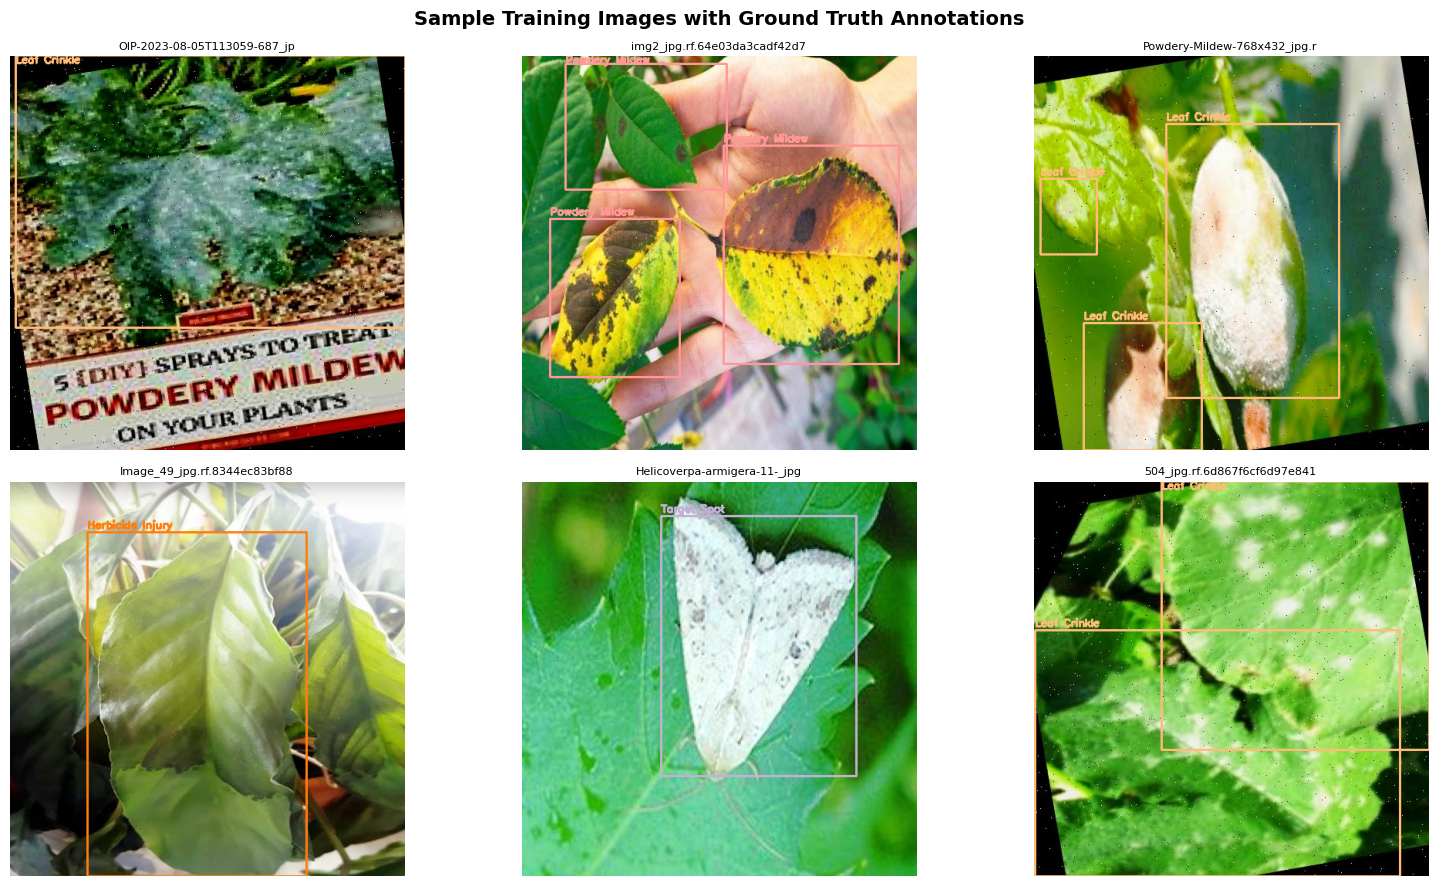

Each bounding box shows the disease region annotated by experts.


In [18]:
# EDA - Step 3.4: Sample Annotated Images
# Visualize random training images with their ground truth bounding boxes
# This helps verify that annotations are correct before training
import cv2
import random
import matplotlib.pyplot as plt
from pathlib import Path

img_dir = Path("/kaggle/working/plant-disease-2/train/images")
lbl_dir = Path("/kaggle/working/plant-disease-2/train/labels")
COLORS  = plt.cm.tab20.colors

# Randomly sample 6 training images
sample_imgs = random.sample(list(img_dir.glob("*.jpg")), 6)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, img_path in zip(axes.flat, sample_imgs):
    # Read image and convert BGR to RGB
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_path = lbl_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls = int(parts[0])
                # YOLOv8 format: cx, cy, bw, bh (normalized 0-1)
                cx, cy, bw, bh = map(float, parts[1:5])
                # Convert to pixel coordinates
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                color = tuple(int(c*255) for c in COLORS[cls % 20][:3])
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                label = disease_names.get(cls, str(cls))
                cv2.putText(img, label, (x1, max(y1-5, 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 2)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name[:28], fontsize=8)

plt.suptitle("Sample Training Images with Ground Truth Annotations",
             fontsize=14, fontweight="bold")
plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/runs/sample_images.png", dpi=150)
plt.show()
print("Each bounding box shows the disease region annotated by experts.")

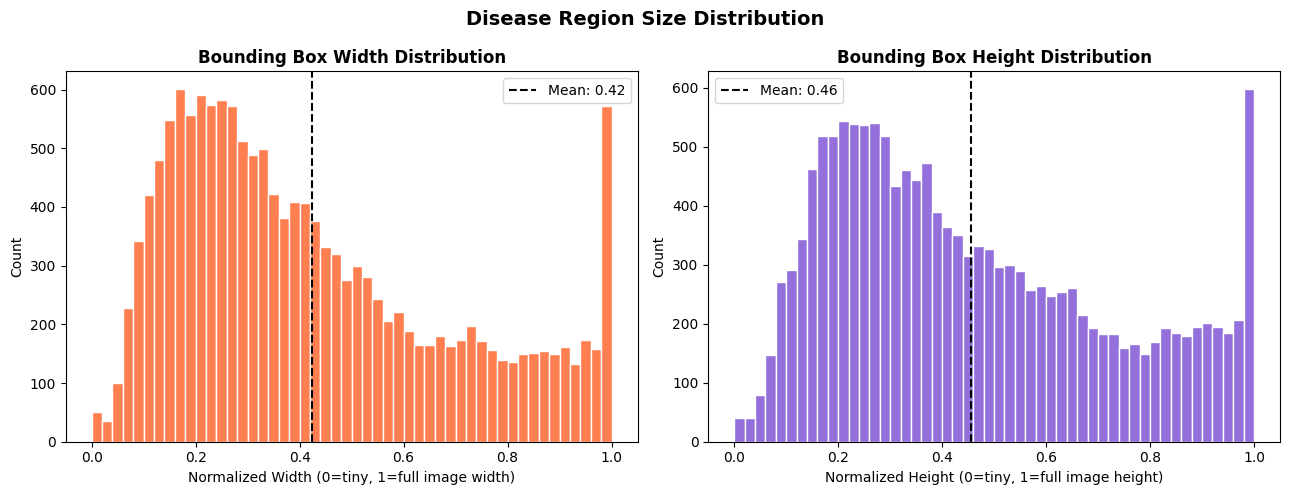

Average box width : 0.423  (normalized)
Average box height: 0.456  (normalized)
Total annotations : 14991

Interpretation: Most disease regions cover 30-60% of the image,
suggesting the camera is typically close to the affected leaf.


In [22]:
# EDA - Step 3.5: Bounding Box Size Distribution
# Analyze the size of disease regions in images
# Small boxes = small lesions; large boxes = widespread disease
import matplotlib.pyplot as plt
from pathlib import Path

label_dir = Path("/kaggle/working/plant-disease-2/train/labels")
widths, heights = [], []

for label_file in label_dir.glob("*.txt"):
    with open(label_file) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                widths.append(float(parts[3]))   # normalized width
                heights.append(float(parts[4]))  # normalized height

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(widths, bins=50, color="coral", edgecolor="white")
axes[0].set_title("Bounding Box Width Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Normalized Width (0=tiny, 1=full image width)")
axes[0].set_ylabel("Count")
axes[0].axvline(sum(widths)/len(widths), color='black', linestyle='--',
                label=f'Mean: {sum(widths)/len(widths):.2f}')
axes[0].legend()

axes[1].hist(heights, bins=50, color="mediumpurple", edgecolor="white")
axes[1].set_title("Bounding Box Height Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Normalized Height (0=tiny, 1=full image height)")
axes[1].set_ylabel("Count")
axes[1].axvline(sum(heights)/len(heights), color='black', linestyle='--',
                label=f'Mean: {sum(heights)/len(heights):.2f}')
axes[1].legend()

plt.suptitle("Disease Region Size Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/runs/bbox_distribution.png", dpi=150)
plt.show()

print(f"Average box width : {sum(widths)/len(widths):.3f}  (normalized)")
print(f"Average box height: {sum(heights)/len(heights):.3f}  (normalized)")
print(f"Total annotations : {len(widths)}")
print("\nInterpretation: Most disease regions cover 30-60% of the image,")
print("suggesting the camera is typically close to the affected leaf.")

## Step 4 — Model Training


In [23]:
# Step 4 — Train YOLOv11s Object Detection Model
# We fine-tune a pretrained YOLOv11s model on our plant disease dataset
# Training takes ~4 hours on a T4 GPU for 100 epochs
# Results are saved locally to the Kaggle working directory

from ultralytics import YOLO

# Load YOLOv11s with pretrained COCO weights (transfer learning)
model = YOLO("yolo11s.pt")

# Train the model
results = model.train(
    data="/kaggle/working/plant-disease-2/data.yaml",  # dataset config
    epochs=100,          # number of training epochs
    imgsz=640,           # input image size
    batch=16,            # batch size (T4 GPU limit)
    name="plant_disease_det_final",  # experiment name
    project="/kaggle/working/runs",  
    optimizer="AdamW",   # adaptive optimizer
    lr0=0.001,           # initial learning rate
    
    # Augmentations
    mosaic=1.0,          # mosaic augmentation
    fliplr=0.5,          # horizontal flip probability
    mixup=0.1,           # mixup augmentation strength
    close_mosaic=10,     # DISABLE mosaic for the last 10 epochs to stabilize metrics
    
    # Handling the 13-Class Imbalance
    cls=2.5,             # Higher penalty for getting the class wrong
    label_smoothing=0.1, # Prevents overconfidence on Class 10 and 11
    
    patience=25,         # early stopping patience
    exist_ok=True,       # allow rerunning without error
)

print("Training complete! Model saved to Kaggle /working/runs directory.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/plant-disease-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, forma

In [26]:
from ultralytics import YOLO

# 1. Load the BEST weights from the first 100-epoch run
# Make sure the path matches where your first run saved the file
model = YOLO("/kaggle/working/runs/plant_disease_det_final/weights/best.pt")

# 2. Start the second training cycle
results = model.train(
    data="/kaggle/working/plant-disease-2/data.yaml",  # Same dataset
    epochs=100,              # 100 additional epochs
    imgsz=640,               # Keep consistent with first run
    batch=32,                #Increase batch size for 2 GPUs! (16 per GPU)
    device='',                 
    name="plant_disease_det_v2", # New name to distinguish from run 1
    project="/kaggle/working/runs", 
    optimizer="AdamW",       # Stick with AdamW as it worked well
    
    # HYPERPARAMETER ADJUSTMENTS BASED ON RUN 1:
    lr0=0.0001,              # Lowered LR (from 0.001) for fine-tuning
    warmup_epochs=0,         # Skip warmup because the model is already "warm"
    
    # Keep augmentations active to prevent overfitting in the second cycle
    mosaic=1.0,              
    fliplr=0.5,              
    mixup=0.1,               
    
    patience=30,             # Early stopping if mAP doesn't improve for 30 epochs
    exist_ok=True            # Overwrites folder if it exists (careful!)
)

print("Second training cycle complete! Check the 'plant_disease_det_v2' folder for results.")

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/plant-disease-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/kaggle/working/runs/plant_disease_det_final/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plant_disease_det_v2, nbs=64, nms=Fals

In [27]:
import shutil
import os
os.chdir('/kaggle/working')
shutil.make_archive('final_presentation_results', 'zip', 'runs')
print("Results zipped! Download 'final_presentation_results.zip' from the output tab.")

Results zipped! Download 'final_presentation_results.zip' from the output tab.


In [28]:
import shutil
import os
from IPython.display import FileLink, display

# 1. Make sure we are in the correct directory
os.chdir('/kaggle/working')

# 2. Define the folder to zip and the output zip file name
folder_to_zip = 'runs'
zip_filename = 'my_yolo_training_backup'

# 3. Check if the folder exists, then zip it
if os.path.exists(folder_to_zip):
    print("Zipping the 'runs' folder... Please wait.")
    shutil.make_archive(zip_filename, 'zip', folder_to_zip)
    print("Successfully zipped!")
    
    # 4. Generate the download link
    print("-" * 50)
    print("Click the link below to download your entire runs folder:")
    display(FileLink(f'{zip_filename}.zip'))
else:
    print("Error: The 'runs' folder was not found. Make sure your training has started or completed.")

Zipping the 'runs' folder... Please wait.
Successfully zipped!
--------------------------------------------------
Click the link below to download your entire runs folder:


/kaggle/working/my_yolo_training_backup.zip

## Step 5 — Training Results & Visualizations
Ultralytics automatically generates helpful plots during training. Let's load and display the overall training results and the confusion matrix to see where the model might be mixing up certain diseases.

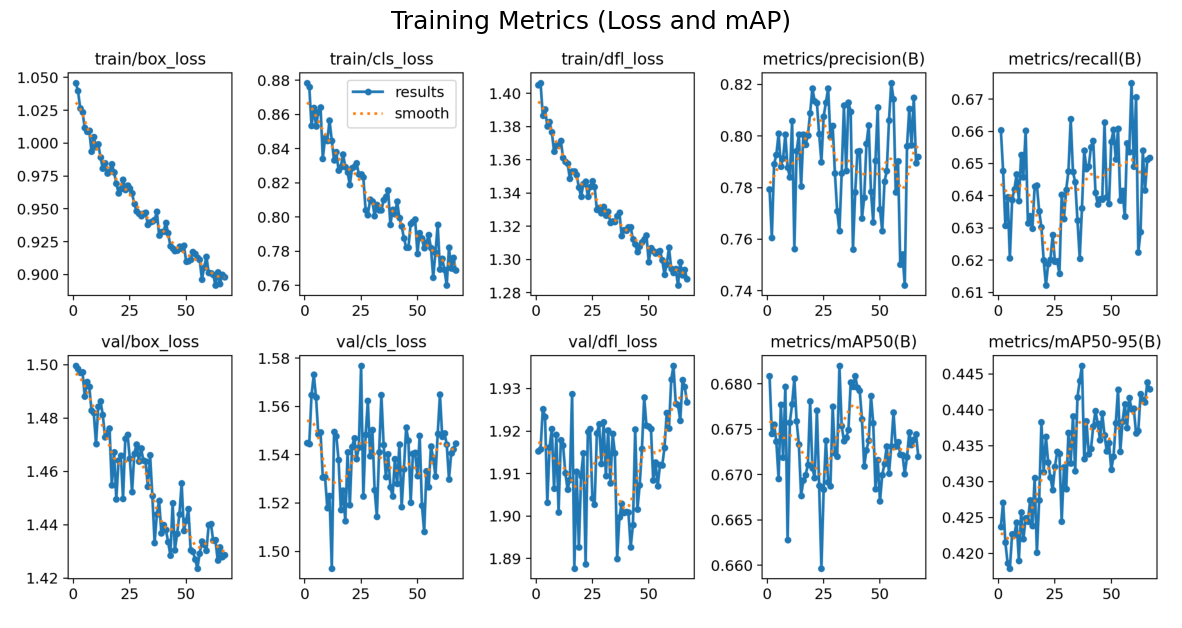

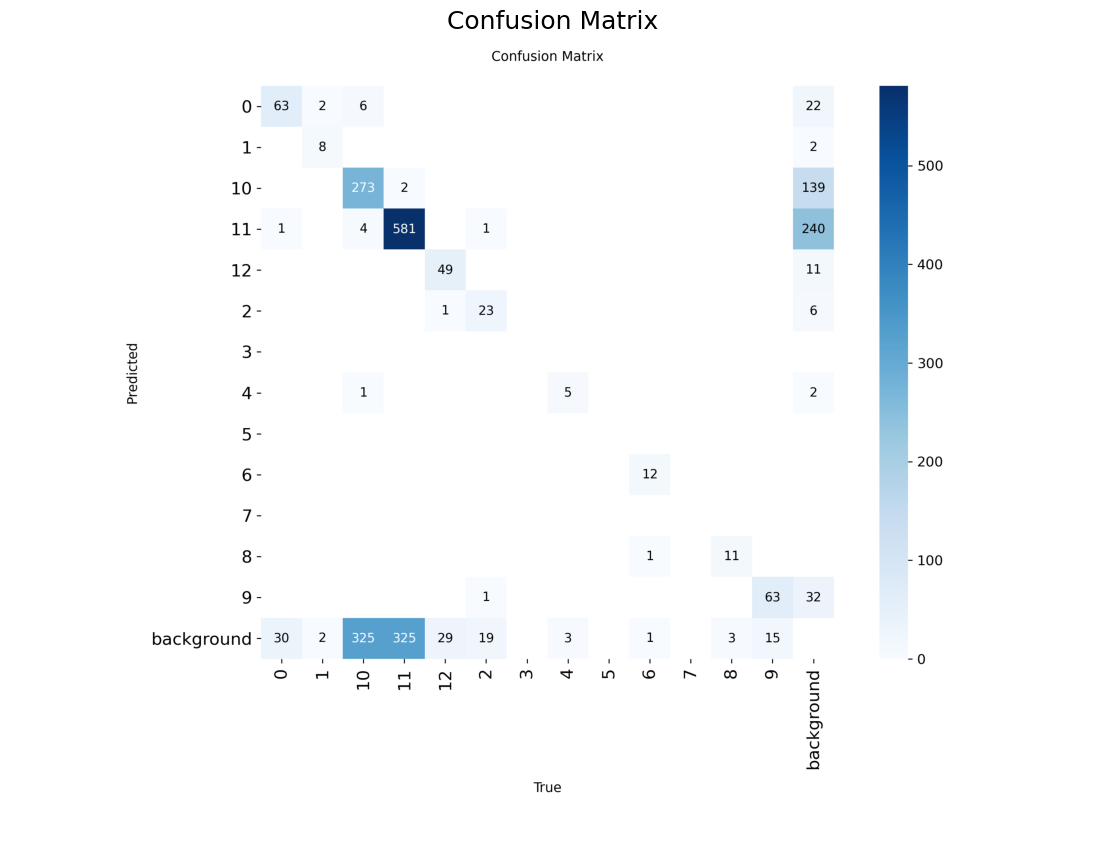

In [29]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# 1. Display the training metrics plot (Losses and mAP over 200 epochs)
results_img_path = "/kaggle/working/runs/plant_disease_det_v2/results.png"

if os.path.exists(results_img_path):
    img = Image.open(results_img_path)
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Training Metrics (Loss and mAP)", fontsize=18)
    plt.show()
else:
    print("Results image not found. Ensure training completed successfully.")

# 2. Display the Confusion Matrix
confusion_matrix_path = "/kaggle/working/runs/plant_disease_det_v2/confusion_matrix.png"

if os.path.exists(confusion_matrix_path):
    img = Image.open(confusion_matrix_path)
    plt.figure(figsize=(14, 14))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Confusion Matrix", fontsize=18)
    plt.show()

## Step 6 — Model Evaluation
Now we load the best weights (`best.pt`) generated from our 200-epoch training run and formally evaluate them against the validation dataset.

In [7]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00a 0:00:01


In [12]:
from ultralytics import YOLO

# The best weights are saved automatically in the runs directory
best_model_path = "/kaggle/input/models/souissidonia/detection/other/default/1/best.pt"

# Load the trained model
best_model = YOLO(best_model_path)

# Validate the model on the validation split
print("Evaluating the best model on the validation dataset...")
metrics = best_model.val()

print("=" * 40)
print("FINAL MODEL METRICS")
print("=" * 40)
print(f"Overall mAP@50    : {metrics.box.map50:.4f}")
print(f"Overall mAP@50-95 : {metrics.box.map:.4f}")
print("=" * 40)

Evaluating the best model on the validation dataset...
Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,417,831 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1062.3±493.8 MB/s, size: 35.3 KB)
val: Scanning /kaggle/working/plant-disease-2/valid/labels... 843 images, 58 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 843/843 1.2Kit/s 0.7s0.1ss
val: New cache created: /kaggle/working/plant-disease-2/valid/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 147, len(boxes) = 1860. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 4.3it/s 12.3s0.2s
                   all        843       1860      0.762      0.668  

## Step 7 — Inference & Visualization (Testing the Model)
Let's take a few random images from the validation set that the model hasn't trained on, run predictions, and visualize the bounding boxes it draws.

Running inference on sample validation images...

0: 640x640 2 11s, 12.7ms
1: 640x640 3 0s, 12.7ms
2: 640x640 1 11, 12.7ms
Speed: 3.6ms preprocess, 12.7ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict


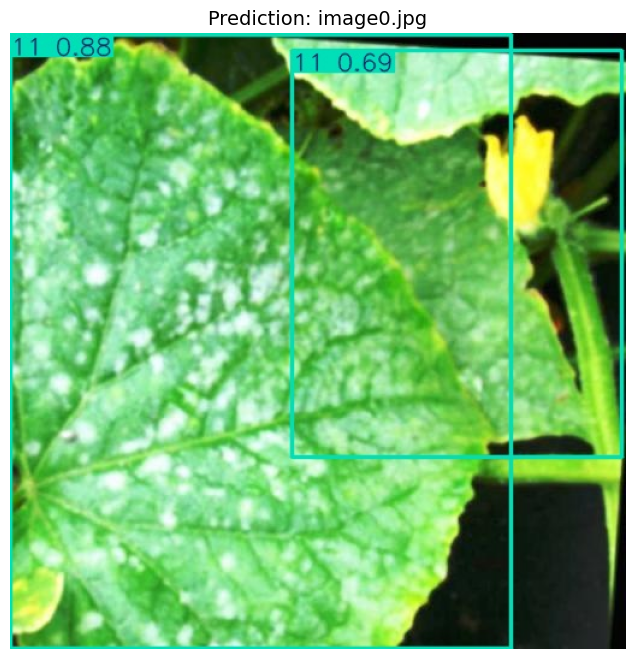

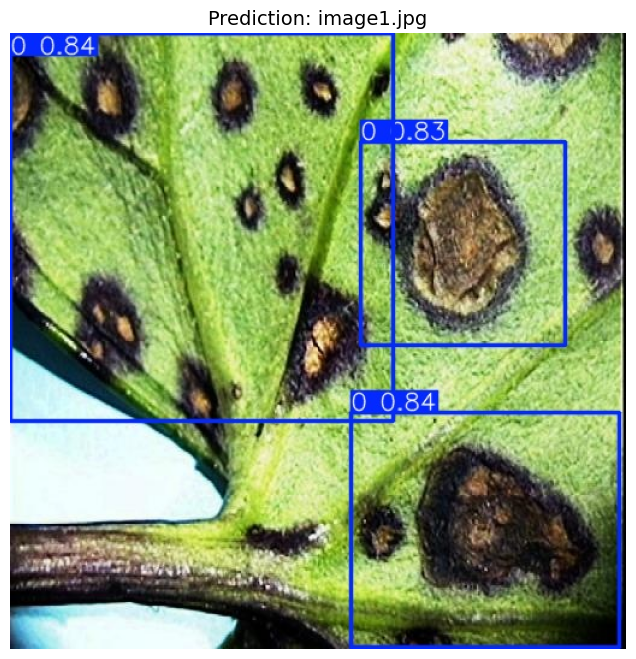

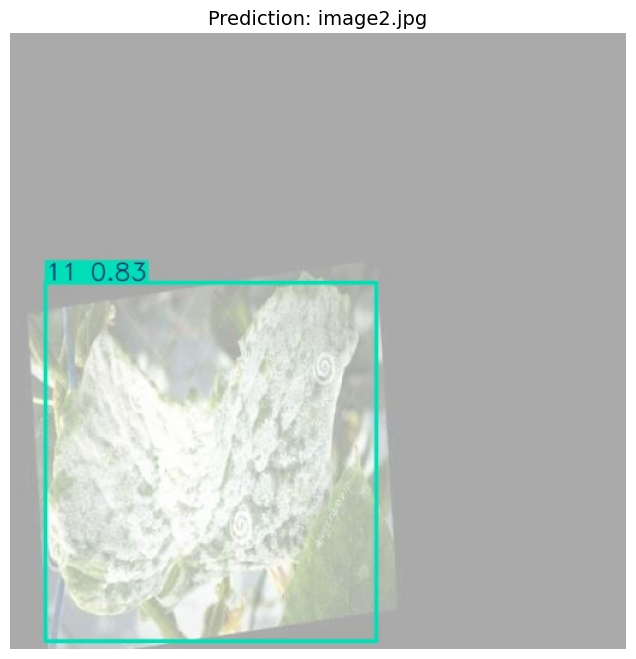

In [21]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

# Get 3 random validation images to test
val_images = glob.glob("/kaggle/working/plant-disease-2/valid/images/*.jpg")[:3]

# Run prediction (setting confidence threshold to 25%)
print("Running inference on sample validation images...")
results = best_model.predict(source=val_images, save=True, conf=0.25)

# Display the predicted images with bounding boxes
for result in results:
    # Ultralytics saves predictions to a newly created 'predict' folder
    pred_img_path = os.path.join(result.save_dir, os.path.basename(result.path))
    
    if os.path.exists(pred_img_path):
        img = Image.open(pred_img_path)
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {os.path.basename(result.path)}", fontsize=14)
        plt.show()

## Step 8 — Export and Download Model Weights
To use this model in a real-world application (like a mobile app or web dashboard), we need to export it to a standard format like ONNX. Finally, we will generate download links so you can save your hard work directly from Kaggle to your local computer!

In [34]:
from IPython.display import FileLink, display

# 1. Export the model to ONNX format (Great for deployment)
print("Exporting the model to ONNX format...")
exported_path = best_model.export(format="onnx", imgsz=640)
print(f"Model exported successfully to: {exported_path}\n")

# 2. Generate Download Links
print("Click the links below to download your weights:")
print("-" * 50)

# Link to the standard PyTorch weights (.pt)
print("PyTorch Format (best.pt):")
display(FileLink(best_model_path))

# Link to the exported ONNX model (.onnx)
if os.path.exists(exported_path):
    print("\nONNX Format (best.onnx):")
    display(FileLink(exported_path))

Exporting the model to ONNX format...
Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/plant_disease_det_v2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 17, 8400) (18.3 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 282ms
Prepared 2 packages in 3.29s
Installed 2 packages in 15ms
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 4.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 6.5s, saved as '/kaggle/working/ru

/kaggle/working/runs/plant_disease_det_v2/weights/best.pt


ONNX Format (best.onnx):


/kaggle/working/runs/plant_disease_det_v2/weights/best.onnx